## 1️⃣ Libraries Import & Data Load

NumPy khud quoted-CSV (jisme commas fields ke andar hote hain jaise product names) reliably parse nahi kar pata, isliye hum Python ke built-in `csv` module se raw rows padhte hain, aur **turant NumPy arrays mein convert** kar dete hain. Uske baad har operation NumPy se hi hota hai.

In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=3)
print("NumPy version:", np.__version__)

NumPy version: 2.4.4


In [2]:
# CSV file ko raw rows ke roop mein padhna
with open('Superstore.csv', 'r', encoding='latin1') as f:
    reader = csv.reader(f)
    header = next(reader)
    rows = [row for row in reader]

print("Total rows:", len(rows))
print("Total columns:", len(header))
print("Header:", header)

Total rows: 9994
Total columns: 21
Header: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [3]:
# Column index mapping banate hain taaki columns ko naam se access kar sakein
col_idx = {name: i for i, name in enumerate(header)}
col_idx

{'Row ID': 0,
 'Order ID': 1,
 'Order Date': 2,
 'Ship Date': 3,
 'Ship Mode': 4,
 'Customer ID': 5,
 'Customer Name': 6,
 'Segment': 7,
 'Country': 8,
 'City': 9,
 'State': 10,
 'Postal Code': 11,
 'Region': 12,
 'Product ID': 13,
 'Category': 14,
 'Sub-Category': 15,
 'Product Name': 16,
 'Sales': 17,
 'Quantity': 18,
 'Discount': 19,
 'Profit': 20}

## 2️⃣ NumPy Arrays Banana (Column-wise)

Har column ko uske sahi dtype ke saath ek alag NumPy array mein convert karte hain — yeh `np.array()` aur dtype specification ka core use-case hai.

In [4]:
# Numeric columns -> float64 NumPy arrays
sales    = np.array([float(r[col_idx['Sales']])    for r in rows], dtype=np.float64)
quantity = np.array([float(r[col_idx['Quantity']])  for r in rows], dtype=np.float64)
discount = np.array([float(r[col_idx['Discount']])  for r in rows], dtype=np.float64)
profit   = np.array([float(r[col_idx['Profit']])    for r in rows], dtype=np.float64)
postal   = np.array([r[col_idx['Postal Code']] for r in rows])

print("sales dtype:", sales.dtype, "| shape:", sales.shape)
print("quantity dtype:", quantity.dtype)
print("discount dtype:", discount.dtype)
print("profit dtype:", profit.dtype)

sales dtype: float64 | shape: (9994,)
quantity dtype: float64
discount dtype: float64
profit dtype: float64


In [5]:
# Categorical columns -> Unicode string NumPy arrays
category    = np.array([r[col_idx['Category']]     for r in rows], dtype='<U30')
subcategory = np.array([r[col_idx['Sub-Category']]  for r in rows], dtype='<U30')
region      = np.array([r[col_idx['Region']]        for r in rows], dtype='<U15')
segment     = np.array([r[col_idx['Segment']]       for r in rows], dtype='<U15')
ship_mode   = np.array([r[col_idx['Ship Mode']]     for r in rows], dtype='<U20')
state       = np.array([r[col_idx['State']]         for r in rows], dtype='<U30')
customer    = np.array([r[col_idx['Customer Name']] for r in rows], dtype='<U50')

print("category array sample:", category[:5])
print("category dtype:", category.dtype)

category array sample: ['Furniture' 'Furniture' 'Office Supplies' 'Furniture' 'Office Supplies']
category dtype: <U30


In [6]:
# Date columns -> np.datetime64 arrays
order_date = np.array([np.datetime64(f"{r[col_idx['Order Date']].split('/')[2]}-"
                                      f"{int(r[col_idx['Order Date']].split('/')[0]):02d}-"
                                      f"{int(r[col_idx['Order Date']].split('/')[1]):02d}")
                        for r in rows], dtype='datetime64[D]')

ship_date = np.array([np.datetime64(f"{r[col_idx['Ship Date']].split('/')[2]}-"
                                     f"{int(r[col_idx['Ship Date']].split('/')[0]):02d}-"
                                     f"{int(r[col_idx['Ship Date']].split('/')[1]):02d}")
                       for r in rows], dtype='datetime64[D]')

print("order_date dtype:", order_date.dtype)
print("First 5 order dates:", order_date[:5])

order_date dtype: datetime64[D]
First 5 order dates: ['2016-11-08' '2016-11-08' '2016-06-12' '2015-10-11' '2015-10-11']


## 3️⃣ Array Inspection — shape, ndim, size, itemsize, nbytes

In [7]:
print("Sales array  -> shape:", sales.shape, "| ndim:", sales.ndim, "| size:", sales.size)
print("Sales array  -> itemsize:", sales.itemsize, "bytes | total nbytes:", sales.nbytes, "bytes")
print("Category array dtype:", category.dtype, "| itemsize:", category.itemsize)

Sales array  -> shape: (9994,) | ndim: 1 | size: 9994
Sales array  -> itemsize: 8 bytes | total nbytes: 79952 bytes
Category array dtype: <U30 | itemsize: 120


In [8]:
# Saare column-arrays ko ek 2D numeric matrix mein combine karna (Sales, Quantity, Discount, Profit)
numeric_matrix = np.column_stack([sales, quantity, discount, profit])
print("Numeric matrix shape:", numeric_matrix.shape)   # (rows, 4 features)
print("ndim:", numeric_matrix.ndim)
numeric_matrix[:5]

Numeric matrix shape: (9994, 4)
ndim: 2


array([[ 261.96 ,    2.   ,    0.   ,   41.914],
       [ 731.94 ,    3.   ,    0.   ,  219.582],
       [  14.62 ,    2.   ,    0.   ,    6.871],
       [ 957.577,    5.   ,    0.45 , -383.031],
       [  22.368,    2.   ,    0.2  ,    2.516]])

## 4️⃣ Reshaping — reshape, transpose, ravel, flatten

In [9]:
# Transpose - features ko rows, observations ko columns bana dena
transposed = numeric_matrix.T
print("Original shape:", numeric_matrix.shape, "-> Transposed shape:", transposed.shape)

Original shape: (9994, 4) -> Transposed shape: (4, 9994)


In [10]:
# reshape - pehle 100 Sales values ko 10x10 grid mein dekhna
sample_sales_grid = sales[:100].reshape(10, 10)
print("Reshaped (10,10) grid:\n", sample_sales_grid[:3])

Reshaped (10,10) grid:
 [[ 261.96   731.94    14.62   957.577   22.368   48.86     7.28   907.152
    18.504  114.9  ]
 [1706.184  911.424   15.552  407.976   68.81     2.544  665.88    55.5
     8.56   213.48 ]
 [  22.72    19.46    60.34    71.372 1044.63    11.648   90.57  3083.43
     9.618  124.2  ]]


In [11]:
# ravel / flatten - wapas 1D mein convert karna
flat_back = sample_sales_grid.ravel()
print("Flattened shape:", flat_back.shape)
print("Original == Flattened first 10:", np.array_equal(sales[:10], flat_back[:10]))

Flattened shape: (100,)
Original == Flattened first 10: True


## 5️⃣ Indexing, Slicing & Boolean Masking

In [12]:
# Basic slicing - pehle 10 sales values
print("First 10 Sales:", sales[:10])
print("Last 5 Sales:", sales[-5:])
print("Every 500th value:", sales[::500])

First 10 Sales: [261.96  731.94   14.62  957.577  22.368  48.86    7.28  907.152  18.504
 114.9  ]
Last 5 Sales: [ 25.248  91.96  258.576  29.6   243.16 ]
Every 500th value: [261.96   22.62   44.02  223.056 199.95   12.224  44.416  62.94   63.47
  23.2    79.99  664.146  91.36   90.06   25.76  140.97  263.96   97.82
   8.226  26.94 ]


In [13]:
# Boolean masking - high value orders (Sales > 1000)
high_value_mask = sales > 1000
print("High-value orders count:", high_value_mask.sum())
print("High-value Sales sample:", sales[high_value_mask][:10])

High-value orders count: 468
High-value Sales sample: [1706.184 1044.63  3083.43  1097.544 1029.95  1113.024 1951.84  8159.952
 1740.06  1188.   ]


In [14]:
# Multiple condition masking - loss-making Furniture orders
furniture_loss_mask = (category == 'Furniture') & (profit < 0)
print("Loss-making Furniture orders:", furniture_loss_mask.sum())
print("Their profit values:", profit[furniture_loss_mask][:10])

Loss-making Furniture orders: 714
Their profit values: [ -383.031    -1.02  -1665.052  -147.963   -46.976   -15.147   -15.223
  -114.391    -5.825   -14.475]


In [15]:
# Fancy indexing - specific indices se values nikalna
top_5_indices = np.array([0, 10, 100, 1000, 5000])
print("Sales at specific indices:", sales[top_5_indices])
print("Category at specific indices:", category[top_5_indices])

Sales at specific indices: [ 261.96  1706.184   95.976   44.02    79.99 ]
Category at specific indices: ['Furniture' 'Furniture' 'Technology' 'Office Supplies' 'Technology']


In [16]:
# np.where - condition ke basis pe values replace karna (Profit_Flag array banate hain)
profit_flag = np.where(profit < 0, 'Loss', 'Gain')
print("Profit flag sample:", profit_flag[:10])
print("Total Loss orders:", np.sum(profit_flag == 'Loss'))
print("Total Gain orders:", np.sum(profit_flag == 'Gain'))

Profit flag sample: ['Gain' 'Gain' 'Gain' 'Loss' 'Gain' 'Gain' 'Gain' 'Gain' 'Gain' 'Gain']
Total Loss orders: 1871
Total Gain orders: 8123


In [17]:
# np.where with 3 args - nested condition (Loss / Low Gain / High Gain)
profit_category = np.where(profit < 0, 'Loss', np.where(profit < 50, 'Low Gain', 'High Gain'))
unique_vals, counts = np.unique(profit_category, return_counts=True)
dict(zip(unique_vals, counts))

{np.str_('High Gain'): np.int64(1728),
 np.str_('Loss'): np.int64(1871),
 np.str_('Low Gain'): np.int64(6395)}

## 6️⃣ np.unique, np.sort & np.argsort

In [18]:
# Unique categories aur unki counts
unique_categories, category_counts = np.unique(category, return_counts=True)
for c, cnt in zip(unique_categories, category_counts):
    print(f"{c}: {cnt}")

Furniture: 2121
Office Supplies: 6026
Technology: 1847


In [19]:
# np.unique with return_inverse -> categorical encoding (label encoding jaisa)
unique_regions, region_codes = np.unique(region, return_inverse=True)
print("Unique regions:", unique_regions)
print("Region codes sample:", region_codes[:10])

Unique regions: ['Central' 'East' 'South' 'West']
Region codes sample: [2 2 3 2 2 3 3 3 3 3]


In [20]:
# np.sort - Sales ko ascending order mein sort karna
sorted_sales = np.sort(sales)
print("Smallest 5 sales:", sorted_sales[:5])
print("Largest 5 sales:", sorted_sales[-5:])

Smallest 5 sales: [0.444 0.556 0.836 0.852 0.876]
Largest 5 sales: [10499.97  11199.968 13999.96  17499.95  22638.48 ]


In [21]:
# np.argsort - Top 5 sabse zyada profit wale orders ke indices nikalna
top5_profit_idx = np.argsort(profit)[-5:][::-1]
print("Top 5 Profit values:", profit[top5_profit_idx])
print("Their Categories:", category[top5_profit_idx])
print("Their Sub-Categories:", subcategory[top5_profit_idx])

Top 5 Profit values: [8399.976 6719.981 5039.986 4946.37  4630.475]
Their Categories: ['Technology' 'Technology' 'Technology' 'Office Supplies'
 'Office Supplies']
Their Sub-Categories: ['Copiers' 'Copiers' 'Copiers' 'Binders' 'Binders']


In [22]:
# Bottom 5 (sabse zyada loss)
bottom5_profit_idx = np.argsort(profit)[:5]
print("Bottom 5 Profit values (biggest losses):", profit[bottom5_profit_idx])
print("Their Categories:", category[bottom5_profit_idx])

Bottom 5 Profit values (biggest losses): [-6599.978 -3839.99  -3701.893 -3399.98  -2929.485]
Their Categories: ['Technology' 'Technology' 'Office Supplies' 'Technology'
 'Office Supplies']


## 7️⃣ Statistical Functions — mean, median, std, var, percentile

In [23]:
print(f"Sales    -> mean: {sales.mean():.2f}, median: {np.median(sales):.2f}, std: {sales.std():.2f}, var: {sales.var():.2f}")
print(f"Profit   -> mean: {profit.mean():.2f}, median: {np.median(profit):.2f}, std: {profit.std():.2f}")
print(f"Discount -> mean: {discount.mean():.3f}, std: {discount.std():.3f}")
print(f"Quantity -> mean: {quantity.mean():.2f}, max: {quantity.max()}, min: {quantity.min()}")

Sales    -> mean: 229.86, median: 54.49, std: 623.21, var: 388395.59
Profit   -> mean: 28.66, median: 8.67, std: 234.25
Discount -> mean: 0.156, std: 0.206
Quantity -> mean: 3.79, max: 14.0, min: 1.0


In [24]:
# min/max aur unke indices (argmin/argmax)
print("Max Sales:", sales.max(), "at index:", sales.argmax())
print("Min Profit (biggest loss):", profit.min(), "at index:", profit.argmin())
print("Order with min profit ->", customer[profit.argmin()], "|", subcategory[profit.argmin()])

Max Sales: 22638.48 at index: 2697
Min Profit (biggest loss): -6599.978 at index: 7772
Order with min profit -> Cindy Stewart | Machines


In [25]:
# np.ptp (peak-to-peak = max - min), sum
print("Sales range (ptp):", np.ptp(sales))
print("Total Sales (sum):", sales.sum())
print("Total Profit (sum):", profit.sum())

Sales range (ptp): 22638.036
Total Sales (sum): 2297200.8603
Total Profit (sum): 286397.0217


In [26]:
# Percentiles / Quartiles
p25, p50, p75, p90 = np.percentile(sales, [25, 50, 75, 90])
print(f"Sales percentiles -> 25th: {p25:.2f}, 50th(median): {p50:.2f}, 75th: {p75:.2f}, 90th: {p90:.2f}")

iqr = p75 - p25
print("IQR (Interquartile Range):", round(iqr, 2))

Sales percentiles -> 25th: 17.28, 50th(median): 54.49, 75th: 209.94, 90th: 572.71
IQR (Interquartile Range): 192.66


## 8️⃣ Group-wise Aggregation using Pure NumPy

NumPy mein `groupby` nahi hota, isliye hum **boolean masking + loop** aur **np.unique(return_inverse)** ke combination se manual group-aggregation karte hain.

In [27]:
# Category-wise Total Sales & Profit (boolean mask approach)
print(f"{'Category':<20}{'Total Sales':>15}{'Total Profit':>15}{'Avg Discount':>15}")
for cat in unique_categories:
    mask = category == cat
    print(f"{cat:<20}{sales[mask].sum():>15.2f}{profit[mask].sum():>15.2f}{discount[mask].mean():>15.3f}")

Category                Total Sales   Total Profit   Avg Discount
Furniture                 741999.80       18451.27          0.174
Office Supplies           719047.03      122490.80          0.157
Technology                836154.03      145454.95          0.132


In [28]:
# Region-wise aggregation using np.unique(return_inverse) + np.bincount (vectorized, fast group-sum)
region_labels, region_codes = np.unique(region, return_inverse=True)
region_total_sales  = np.bincount(region_codes, weights=sales)
region_total_profit = np.bincount(region_codes, weights=profit)
region_order_count  = np.bincount(region_codes)

for i, r in enumerate(region_labels):
    print(f"{r:<10} -> Orders: {int(region_order_count[i]):>5} | Sales: {region_total_sales[i]:>12.2f} | Profit: {region_total_profit[i]:>10.2f}")

Central    -> Orders:  2323 | Sales:    501239.89 | Profit:   39706.36
East       -> Orders:  2848 | Sales:    678781.24 | Profit:   91522.78
South      -> Orders:  1620 | Sales:    391721.91 | Profit:   46749.43
West       -> Orders:  3203 | Sales:    725457.82 | Profit:  108418.45


In [29]:
# Sub-Category wise average Profit Margin % using vectorized groupby-style computation
subcat_labels, subcat_codes = np.unique(subcategory, return_inverse=True)
subcat_sales  = np.bincount(subcat_codes, weights=sales)
subcat_profit = np.bincount(subcat_codes, weights=profit)
subcat_margin = (subcat_profit / subcat_sales) * 100

order = np.argsort(subcat_margin)[::-1]
print(f"{'Sub-Category':<20}{'Margin %':>10}")
for i in order:
    print(f"{subcat_labels[i]:<20}{subcat_margin[i]:>10.2f}")

Sub-Category          Margin %


Labels                   44.42
Paper                    43.39
Envelopes                42.27
Copiers                  37.20
Fasteners                31.40
Accessories              25.05
Art                      24.07
Appliances               16.87
Binders                  14.86
Furnishings              14.24
Phones                   13.49
Storage                   9.51
Chairs                    8.10
Machines                  1.79
Supplies                 -2.55
Bookcases                -3.02
Tables                   -8.56


## 9️⃣ Cumulative Functions — cumsum, cumprod, diff

In [30]:
# Date order se sort karke Sales ka cumulative sum (running total revenue)
sort_by_date = np.argsort(order_date)
sales_by_date = sales[sort_by_date]
dates_sorted = order_date[sort_by_date]

cumulative_sales = np.cumsum(sales_by_date)
print("Running total after first order:", cumulative_sales[0])
print("Running total after 1000 orders:", cumulative_sales[999])
print("Final cumulative total (Grand Total Sales):", cumulative_sales[-1])

Running total after first order: 16.448
Running total after 1000 orders: 228666.76709999988
Final cumulative total (Grand Total Sales): 2297200.8602999486


In [31]:
# np.diff - consecutive orders ke beech sales mein day-to-day difference
sales_diff = np.diff(sales_by_date[:20])
print("Difference between consecutive order sales (first 20):")
print(sales_diff)

Difference between consecutive order sales (first 20):
[   -4.664   260.952  -269.196    15.996   -14.056  2568.34  -1963.84
  -597.2     379.2     363.98   -724.84    -24.58     12.9      57.288
   -66.298    -1.086    21.856    20.74    -49.05 ]


In [32]:
# cumprod ka chota demo - discount multipliers ka compounding effect (illustrative)
sample_discounts = 1 - discount[:5]   # e.g. 0.9 matlab 10% discount
compounded = np.cumprod(sample_discounts)
print("Individual retention factors:", sample_discounts)
print("Compounded (cumulative product):", compounded)

Individual retention factors: [1.   1.   1.   0.55 0.8 ]
Compounded (cumulative product): [1.   1.   1.   0.55 0.44]


## 🔟 Correlation & Covariance — np.corrcoef, np.cov

In [33]:
# Correlation matrix banate hain 4 numeric features ke beech
corr_matrix = np.corrcoef([sales, quantity, discount, profit])
labels = ['Sales','Quantity','Discount','Profit']
print(f"{'':<10}" + "".join([f"{l:>10}" for l in labels]))
for i, l in enumerate(labels):
    print(f"{l:<10}" + "".join([f"{corr_matrix[i,j]:>10.3f}" for j in range(4)]))

               Sales  Quantity  Discount    Profit
Sales          1.000     0.201    -0.028     0.479
Quantity       0.201     1.000     0.009     0.066
Discount      -0.028     0.009     1.000    -0.219
Profit         0.479     0.066    -0.219     1.000


In [34]:
# Covariance matrix
cov_matrix = np.cov([sales, profit])
print("Covariance between Sales & Profit:\n", cov_matrix)
print(f"\nSales-Profit correlation coefficient: {corr_matrix[0,3]:.4f}")

Covariance between Sales & Profit:
 [[388434.455  69944.097]
 [ 69944.097  54877.798]]

Sales-Profit correlation coefficient: 0.4791


## 1️⃣1️⃣ Broadcasting & Vectorized Arithmetic

In [35]:
# Broadcasting example - har order ka profit margin % (element-wise vectorized division)
profit_margin_pct = (profit / sales) * 100
print("Profit margin % (first 10):", np.round(profit_margin_pct[:10], 2))
print("Average profit margin across all orders:", round(profit_margin_pct.mean(), 2), "%")

Profit margin % (first 10): [ 16.    30.    47.   -40.    11.25  29.    27.    10.    31.25  30.  ]
Average profit margin across all orders: 12.03 %


In [36]:
# Broadcasting - agar hum uniform 5% extra discount de dein to naya revenue kaisa hoga (scalar broadcast)
simulated_new_sales = sales * (1 - 0.05)
print("Original total Sales:", round(sales.sum(), 2))
print("Simulated total Sales after extra 5% discount:", round(simulated_new_sales.sum(), 2))
print("Revenue impact:", round(simulated_new_sales.sum() - sales.sum(), 2))

Original total Sales: 2297200.86
Simulated total Sales after extra 5% discount: 2182340.82
Revenue impact: -114860.04


In [37]:
# np.clip - Discount values ko ek range mein force karna (0% se 30% tak cap)
clipped_discount = np.clip(discount, 0, 0.30)
print("Original max discount:", discount.max())
print("Clipped max discount:", clipped_discount.max())
print("Number of values that were clipped:", np.sum(discount > 0.30))

Original max discount: 0.8
Clipped max discount: 0.3
Number of values that were clipped: 1166


In [38]:
# np.round, np.abs, np.sqrt, np.log - basic math transformations
print("Rounded Sales (2 decimals):", np.round(sales[:5], 2))
print("Absolute Profit values:", np.abs(profit[:5]))
print("Sqrt of Sales (variance stabilizing):", np.round(np.sqrt(sales[:5]), 2))
print("Log of Sales (log-transform, useful for skewed data):", np.round(np.log1p(sales[:5]), 2))

Rounded Sales (2 decimals): [261.96 731.94  14.62 957.58  22.37]
Absolute Profit values: [ 41.914 219.582   6.871 383.031   2.516]
Sqrt of Sales (variance stabilizing): [16.19 27.05  3.82 30.94  4.73]
Log of Sales (log-transform, useful for skewed data): [5.57 6.6  2.75 6.87 3.15]


## 1️⃣2️⃣ Distribution Analysis — np.histogram & np.bincount

In [39]:
# Sales ka histogram - distribution dekhna
hist_counts, bin_edges = np.histogram(sales, bins=10)
print(f"{'Bin Range':<25}{'Count':>10}")
for i in range(len(hist_counts)):
    print(f"{bin_edges[i]:>8.1f} - {bin_edges[i+1]:<10.1f}{hist_counts[i]:>10}")

Bin Range                     Count


     0.4 - 2264.2          9876
  2264.2 - 4528.1            91
  4528.1 - 6791.9            13
  6791.9 - 9055.7             6
  9055.7 - 11319.5            5
 11319.5 - 13583.3            0
 13583.3 - 15847.1            1
 15847.1 - 18110.9            1
 18110.9 - 20374.7            0
 20374.7 - 22638.5            1


In [40]:
# Quantity ka bincount (chhote integer values ke liye fast frequency count)
quantity_int = quantity.astype(int)
qty_bincount = np.bincount(quantity_int)
print("Quantity value -> frequency:")
for qty_val, cnt in enumerate(qty_bincount):
    if cnt > 0:
        print(f"  Qty={qty_val}: {cnt} orders")

Quantity value -> frequency:
  Qty=1: 899 orders
  Qty=2: 2402 orders
  Qty=3: 2409 orders
  Qty=4: 1191 orders
  Qty=5: 1230 orders
  Qty=6: 572 orders
  Qty=7: 606 orders
  Qty=8: 257 orders
  Qty=9: 258 orders
  Qty=10: 57 orders
  Qty=11: 34 orders
  Qty=12: 23 orders
  Qty=13: 27 orders
  Qty=14: 29 orders


## 1️⃣3️⃣ Trend Analysis — np.polyfit (Linear Regression)

In [41]:
# Monthly total sales nikal ke usme ek linear trend line fit karte hain (np.polyfit)
months_since_start = ((dates_sorted - dates_sorted[0]).astype('timedelta64[D]').astype(int) // 30)
n_months = months_since_start.max() + 1
monthly_totals = np.bincount(months_since_start, weights=sales_by_date, minlength=n_months)

x = np.arange(len(monthly_totals))
y = monthly_totals

# Degree-1 polynomial fit (straight line: y = mx + c)
slope, intercept = np.polyfit(x, y, deg=1)
print(f"Trend line: Sales = {slope:.2f} * month + {intercept:.2f}")
print("Interpretation:", "Sales badh rahi hai har month" if slope > 0 else "Sales ghat rahi hai har month")

Trend line: Sales = 803.53 * month + 27596.84
Interpretation: Sales badh rahi hai har month


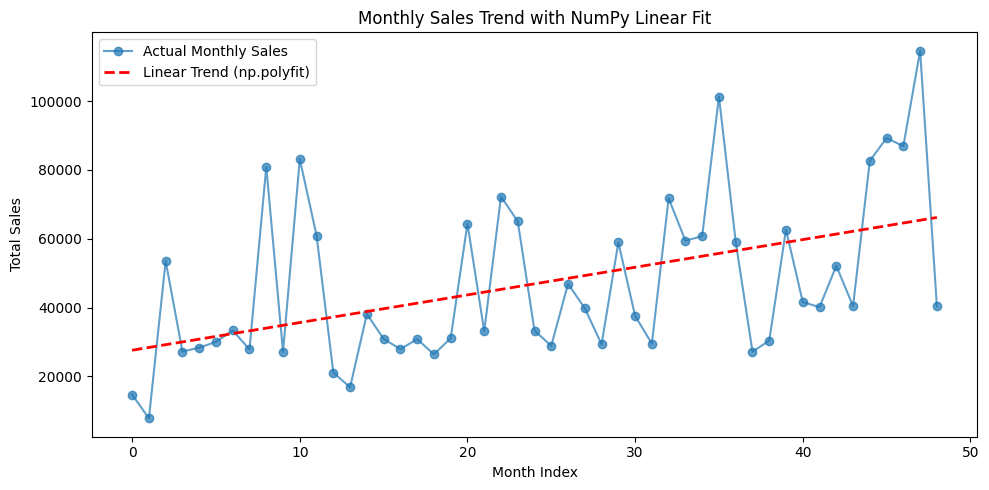

In [42]:
# Trend line visualize karna
predicted = slope * x + intercept

plt.figure(figsize=(10,5))
plt.plot(x, y, 'o-', label='Actual Monthly Sales', alpha=0.7)
plt.plot(x, predicted, 'r--', label='Linear Trend (np.polyfit)', linewidth=2)
plt.xlabel('Month Index')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend with NumPy Linear Fit')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# np.linalg.lstsq - same regression ko least-squares matrix approach se solve karna
A = np.vstack([x, np.ones(len(x))]).T
result = np.linalg.lstsq(A, y, rcond=None)
slope_lstsq, intercept_lstsq = result[0]
print(f"lstsq -> slope: {slope_lstsq:.2f}, intercept: {intercept_lstsq:.2f}")
print("polyfit aur lstsq dono se same result milta hai:", np.isclose(slope, slope_lstsq))

lstsq -> slope: 803.53, intercept: 27596.84
polyfit aur lstsq dono se same result milta hai: True


## 1️⃣4️⃣ Combining & Splitting Arrays

In [44]:
# concatenate - do saalon ka Sales data alag nikal ke wapas jodna
years = np.array([d.astype('datetime64[Y]').astype(int) + 1970 for d in order_date])
sales_2016 = sales[years == 2016]
sales_2017 = sales[years == 2017]
combined_sales = np.concatenate([sales_2016, sales_2017])
print("2016 orders:", len(sales_2016), "| 2017 orders:", len(sales_2017), "| Combined:", len(combined_sales))

2016 orders: 2587 | 2017 orders: 3312 | Combined: 5899


In [45]:
# vstack / hstack - arrays ko vertically/horizontally jodna
v_stacked = np.vstack([sales[:5], profit[:5]])
print("Vertically stacked (Sales & Profit rows):\n", v_stacked)

h_stacked = np.hstack([sales[:5], profit[:5]])
print("\nHorizontally stacked (single long array):\n", h_stacked)

Vertically stacked (Sales & Profit rows):
 [[ 261.96   731.94    14.62   957.577   22.368]
 [  41.914  219.582    6.871 -383.031    2.516]]

Horizontally stacked (single long array):
 [ 261.96   731.94    14.62   957.577   22.368   41.914  219.582    6.871
 -383.031    2.516]


In [46]:
# split - numeric_matrix ko 2 halves mein split karna
first_half, second_half = np.split(numeric_matrix, 2)
print("First half shape:", first_half.shape, "| Second half shape:", second_half.shape)

First half shape: (4997, 4) | Second half shape: (4997, 4)


## 1️⃣5️⃣ np.random — Sampling & Bootstrap Confidence Interval

Yahan hum NumPy ke `random` module se **bootstrap resampling** karte hain taaki Average Profit ka confidence interval estimate kar sakein — yeh statistics mein ek real-world NumPy use-case hai.

In [47]:
rng = np.random.default_rng(seed=42)   # reproducible random generator

# Simple random sample - 5 random orders dekhna
random_indices = rng.integers(0, len(sales), size=5)
print("Randomly sampled Sales:", sales[random_indices])

Randomly sampled Sales: [  4.54  12.42 139.92  43.92  18.  ]


In [48]:
# Bootstrap resampling - 1000 baar random sample lekar mean profit ka distribution banate hain
n_bootstrap = 1000
bootstrap_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    sample = rng.choice(profit, size=len(profit), replace=True)
    bootstrap_means[i] = sample.mean()

ci_lower, ci_upper = np.percentile(bootstrap_means, [2.5, 97.5])
print(f"Observed Mean Profit: {profit.mean():.2f}")
print(f"95% Bootstrap Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

Observed Mean Profit: 28.66
95% Bootstrap Confidence Interval: [24.36, 33.54]


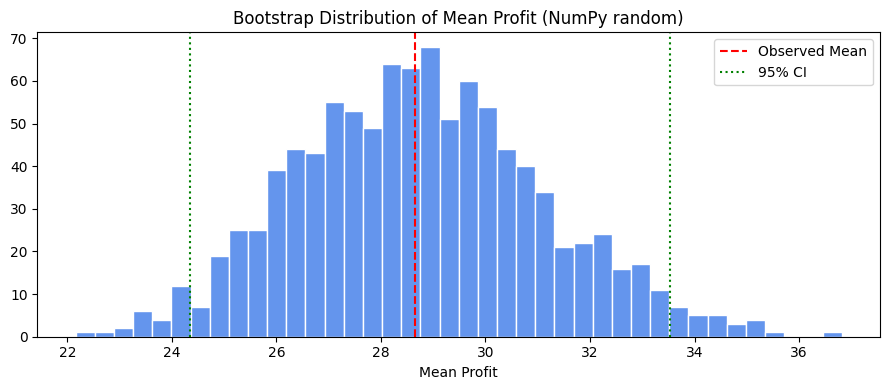

In [49]:
plt.figure(figsize=(9,4))
plt.hist(bootstrap_means, bins=40, color='cornflowerblue', edgecolor='white')
plt.axvline(profit.mean(), color='red', linestyle='--', label='Observed Mean')
plt.axvline(ci_lower, color='green', linestyle=':', label='95% CI')
plt.axvline(ci_upper, color='green', linestyle=':')
plt.title('Bootstrap Distribution of Mean Profit (NumPy random)')
plt.xlabel('Mean Profit')
plt.legend()
plt.tight_layout()
plt.show()

## 1️⃣6️⃣ Missing Value (NaN) Handling

In [50]:
# Check karte hain ki original data mein NaN hai ya nahi
print("Any NaN in Sales?:", np.isnan(sales).any())
print("Any NaN in Profit?:", np.isnan(profit).any())
print("Total NaNs across dataset: 0 (Superstore dataset clean hai)")

Any NaN in Sales?: False
Any NaN in Profit?: False
Total NaNs across dataset: 0 (Superstore dataset clean hai)


In [51]:
# Demo ke liye artificially kuch NaN insert karte hain aur unhe handle karte hain
demo_sales = sales.copy()
demo_sales[np.array([5, 50, 500])] = np.nan

print("NaN count in demo array:", np.isnan(demo_sales).sum())
print("Regular mean (NaN se corrupt ho jaata hai):", demo_sales.mean())   # -> nan
print("nanmean (NaN ignore karke sahi mean):", np.nanmean(demo_sales))
print("nanstd:", np.nanstd(demo_sales))
print("nansum:", np.nansum(demo_sales))

NaN count in demo array:

 3
Regular mean (NaN se corrupt ho jaata hai): nan
nanmean (NaN ignore karke sahi mean): 229.91234113702328
nanstd: 623.2994761248151
nansum: 2297054.2002999997


In [52]:
# NaN ko fill karna (imputation) - nanmean se replace
clean_sales = np.where(np.isnan(demo_sales), np.nanmean(demo_sales), demo_sales)
print("After filling NaN, any NaN left?:", np.isnan(clean_sales).any())

After filling NaN, any NaN left?: False


## 1️⃣7️⃣ Date & Time Arrays — datetime64 / timedelta64

In [53]:
# Shipping duration nikalna (Ship Date - Order Date) using timedelta64
shipping_days = (ship_date - order_date).astype('timedelta64[D]').astype(int)
print("Average shipping days:", round(shipping_days.mean(), 2))
print("Max shipping days:", shipping_days.max())
print("Min shipping days:", shipping_days.min())

Average shipping days: 3.96
Max shipping days: 7
Min shipping days: 0


In [54]:
# Year aur Month extract karna datetime64 se
order_year  = order_date.astype('datetime64[Y]').astype(int) + 1970
order_month = order_date.astype('datetime64[M]').astype(int) % 12 + 1

print("Years present:", np.unique(order_year))
print("Order counts per year:")
yrs, yr_counts = np.unique(order_year, return_counts=True)
for yr_val, c in zip(yrs, yr_counts):
    print(f"  {yr_val}: {c} orders")

Years present: [2014 2015 2016 2017]
Order counts per year:
  2014: 1993 orders
  2015: 2102 orders
  2016: 2587 orders
  2017: 3312 orders


In [55]:
# Weekday extract karna (0=Monday ... 6=Sunday) using datetime64 modular arithmetic
# datetime64[D] epoch (1970-01-01) ek Thursday tha, isliye offset 4 use karte hain
weekday = (order_date.astype('datetime64[D]').astype(int) + 4) % 7
weekday_names = np.array(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])[weekday]
wd_unique, wd_counts = np.unique(weekday_names, return_counts=True)
for wd, c in zip(wd_unique, wd_counts):
    print(f"{wd}: {c} orders")

Fri: 1463 orders
Mon: 1710 orders
Sat: 1818 orders
Sun: 1655 orders
Thu: 371 orders
Tue: 1871 orders
Wed: 1106 orders


## 1️⃣8️⃣ Structured Arrays (Record Arrays)

In [56]:
# Ek structured array banate hain jisme different dtypes ek hi array mein combine hote hain
dtype_struct = np.dtype([
    ('category', '<U20'),
    ('sales', 'f8'),
    ('profit', 'f8'),
    ('quantity', 'i4')
])

structured_data = np.zeros(len(sales), dtype=dtype_struct)
structured_data['category'] = category
structured_data['sales'] = sales
structured_data['profit'] = profit
structured_data['quantity'] = quantity.astype(int)

print("Structured array dtype:", structured_data.dtype)
print("\nFirst 3 records:")
structured_data[:3]

Structured array dtype: [('category', '<U20'), ('sales', '<f8'), ('profit', '<f8'), ('quantity', '<i4')]

First 3 records:


array([('Furniture', 261.96,  41.914, 2),
       ('Furniture', 731.94, 219.582, 3),
       ('Office Supplies',  14.62,   6.871, 2)],
      dtype=[('category', '<U20'), ('sales', '<f8'), ('profit', '<f8'), ('quantity', '<i4')])

In [57]:
# Structured array ko field-name se access karna, aur sort karna profit ke basis pe
top_structured = np.sort(structured_data, order='profit')[::-1][:5]
for rec in top_structured:
    print(f"Category: {rec['category']:<20} Sales: {rec['sales']:>10.2f} Profit: {rec['profit']:>10.2f}")

Category: Technology           Sales:   17499.95 Profit:    8399.98
Category: Technology           Sales:   13999.96 Profit:    6719.98
Category: Technology           Sales:   10499.97 Profit:    5039.99
Category: Office Supplies      Sales:    9892.74 Profit:    4946.37
Category: Office Supplies      Sales:    9449.95 Profit:    4630.48


## 1️⃣9️⃣ Saving Results — np.save, np.savetxt, np.load

In [58]:
# Numeric matrix ko binary .npy format mein save karna (fast, NumPy-native)
np.save('numeric_matrix.npy', numeric_matrix)

# Region-wise summary ko text/csv format mein save karna
summary_array = np.column_stack([region_labels, region_total_sales.astype(str), region_total_profit.astype(str)])
np.savetxt('region_summary.csv', summary_array, delimiter=',', fmt='%s',
           header='Region,Total_Sales,Total_Profit', comments='')

print("Saved: numeric_matrix.npy aur region_summary.csv")

Saved: numeric_matrix.npy aur region_summary.csv


In [59]:
# Wapas load karke verify karna
loaded_matrix = np.load('numeric_matrix.npy')
print("Loaded matrix shape:", loaded_matrix.shape)
print("Original == Loaded:", np.array_equal(numeric_matrix, loaded_matrix))

Loaded matrix shape: (9994, 4)
Original == Loaded: True


## 2️⃣0️⃣ Business Summary — Key Insights (Pure NumPy)

In [60]:
total_sales = sales.sum()
total_profit = profit.sum()
total_orders = sales.size
avg_discount = discount.mean()
overall_margin = (total_profit / total_sales) * 100

best_region_idx = np.argmax(region_total_profit)
worst_subcat_idx = np.argmin(subcat_profit)

print(f"📦 Total Orders          : {total_orders:,}")
print(f"💰 Total Sales           : ${total_sales:,.2f}")
print(f"📈 Total Profit          : ${total_profit:,.2f}")
print(f"🏷️  Average Discount      : {avg_discount*100:.2f}%")
print(f"📊 Overall Profit Margin : {overall_margin:.2f}%")
print(f"🏆 Best Performing Region: {region_labels[best_region_idx]} (Profit: ${region_total_profit[best_region_idx]:,.2f})")
print(f"⚠️  Weakest Sub-Category  : {subcat_labels[worst_subcat_idx]} (Margin: {subcat_margin[worst_subcat_idx]:.2f}%)")
print(f"🚚 Avg Shipping Days     : {shipping_days.mean():.2f} days")

📦 Total Orders          : 9,994
💰 Total Sales           : $2,297,200.86
📈 Total Profit          : $286,397.02
🏷️  Average Discount      : 15.62%
📊 Overall Profit Margin : 12.47%
🏆 Best Performing Region: West (Profit: $108,418.45)
⚠️  Weakest Sub-Category  : Tables (Margin: -8.56%)
🚚 Avg Shipping Days     : 3.96 days


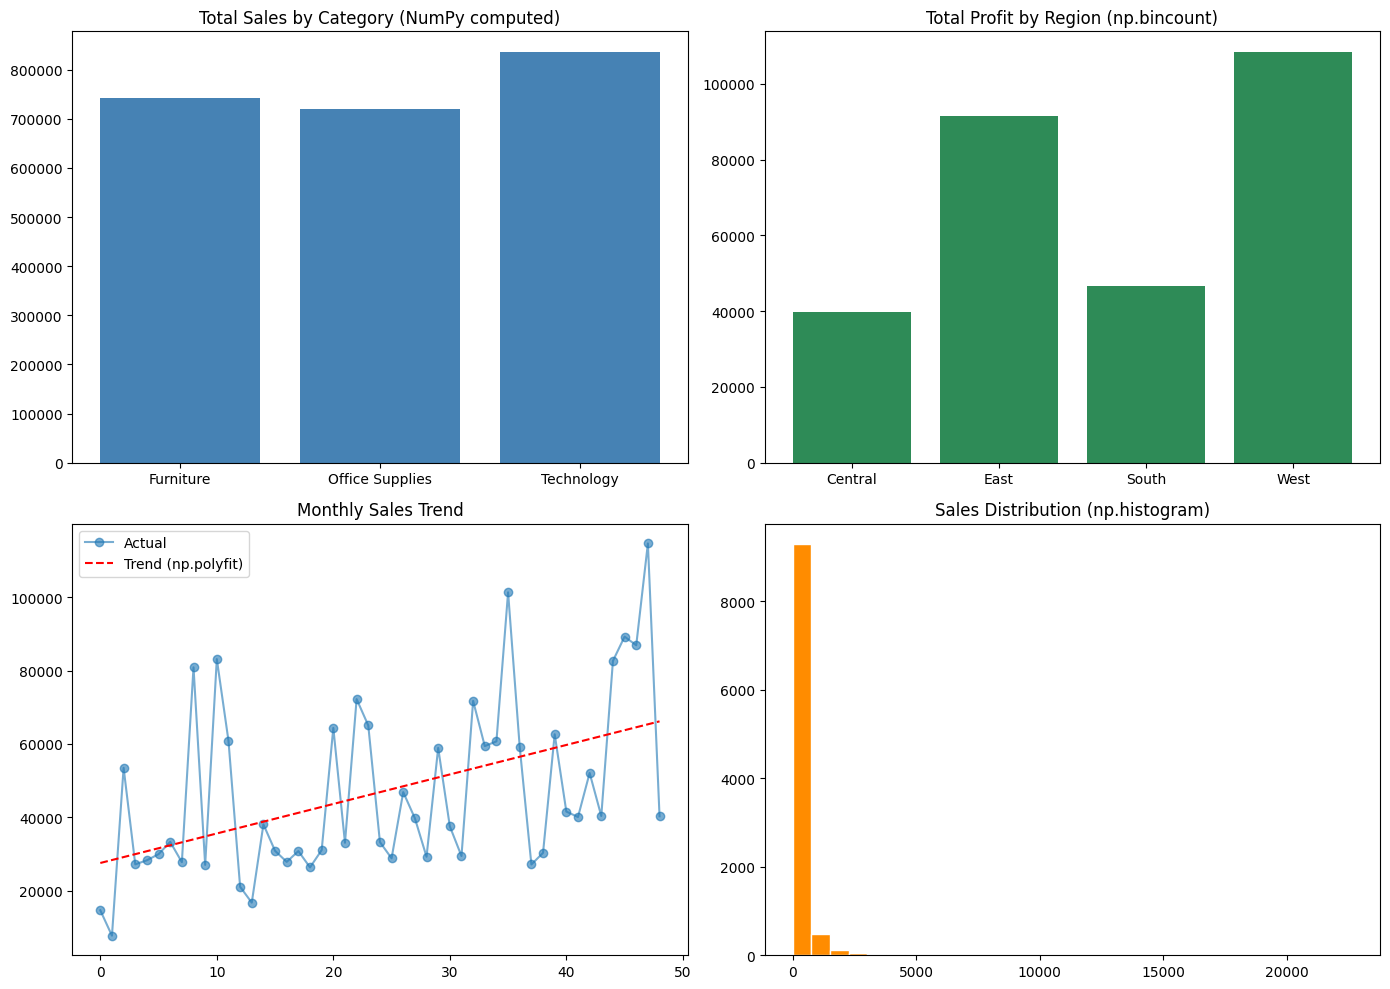

In [61]:
# Final visualization dashboard - sab kuch pure numpy computed values se
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes[0,0].bar(unique_categories, [sales[category==c].sum() for c in unique_categories], color='steelblue')
axes[0,0].set_title('Total Sales by Category (NumPy computed)')

axes[0,1].bar(region_labels, region_total_profit, color='seagreen')
axes[0,1].set_title('Total Profit by Region (np.bincount)')

axes[1,0].plot(x, y, 'o-', alpha=0.6, label='Actual')
axes[1,0].plot(x, predicted, 'r--', label='Trend (np.polyfit)')
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].legend()

axes[1,1].hist(sales, bins=30, color='darkorange', edgecolor='white')
axes[1,1].set_title('Sales Distribution (np.histogram)')

plt.tight_layout()
plt.show()